# **PERFORMA ALGORITMA SINECOSINE PADA TUNING PARAMETER LSTM UNTUK PREDIKSI KUALITAS UDARA PM2.5**

# **1. OBTAIN**


**1.1 Mengumpulkan Dataset**

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
# Baca file CSV dari Google Drive
df = pd.read_csv('/content/drive/My Drive/SkripsiLebColeb/global_air_quality.csv')

#print("10 tampilan awal data:")
display(df.head(10))

#print("\n10 tampilan akhir data:")
display(df.tail(10))

Mounted at /content/drive


,City,Country,Date,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
0,Bangkok,Thailand,2023-03-19,86.57,25.19,99.88,30.63,4.46,36.29,17.67,59.35,13.76
1,Istanbul,Turkey,2023-02-16,50.63,97.39,48.14,8.71,3.40,144.16,3.46,67.51,6.36
2,Rio de Janeiro,Brazil,2023-11-13,130.21,57.22,98.51,9.92,0.12,179.31,25.29,29.30,12.87
3,Mumbai,India,2023-03-16,119.70,130.52,10.96,33.03,7.74,38.65,23.15,99.97,7.71
4,Paris,France,2023-04-04,55.20,36.62,76.85,21.85,2.00,67.09,16.02,90.28,14.16
5,Los Angeles,USA,2023-01-05,121.28,196.39,86.17,28.74,2.64,46.86,18.53,43.01,3.96
6,Tokyo,Japan,2023-09-17,118.76,15.69,12.99,39.05,3.04,15.75,-1.37,17.76,17.66
7,New York,USA,2023-11-23,72.52,23.43,92.01,15.26,4.57,106.50,32.14,76.57,9.42
8,Tokyo,Japan,2023-09-21,131.46,145.57,10.13,25.10,9.08,181.72,-6.20,71.42,16.81
9,London,UK,2023-09-13,64.71,92.84,92.98,36.40,3.68,88.44,19.80,45.92,2.56


,City,Country,Date,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
9990,Madrid,Spain,2023-06-14,27.23,162.53,53.71,41.84,4.42,134.94,15.05,21.66,13.42
9991,Toronto,Canada,2023-05-22,141.84,164.42,99.78,36.30,7.00,155.58,22.44,89.57,6.38
9992,Rio de Janeiro,Brazil,2023-04-20,45.07,164.31,20.08,1.08,2.29,64.84,10.25,73.18,9.23
9993,Bangkok,Thailand,2023-06-05,82.04,109.58,97.12,9.64,8.53,46.72,3.03,82.68,3.35
9994,Bangkok,Thailand,2023-07-15,70.87,159.09,51.73,44.28,5.53,31.66,34.26,71.78,2.70
9995,Johannesburg,South Africa,2023-09-16,147.85,184.34,90.33,34.93,2.81,191.45,-1.92,65.22,15.48
9996,Berlin,Germany,2023-12-05,12.22,121.49,49.04,5.66,2.10,184.56,-9.81,12.16,10.75
9997,Moscow,Russia,2023-11-26,44.07,143.62,8.41,32.58,0.69,167.68,39.35,53.95,4.56
9998,Berlin,Germany,2023-02-03,67.43,96.79,43.23,29.19,6.01,148.50,26.21,58.54,2.71
9999,Bangkok,Thailand,2023-06-13,16.34,28.80,50.48,21.20,0.49,17.41,2.50,66.05,5.01


# **Negara dan Kota**

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
df_location = pd.read_csv('/content/drive/My Drive/SkripsiLebColeb/global_air_quality.csv')

# Get unique country-city pairs
unique_locations = df_location[['Country', 'City']].drop_duplicates().sort_values(by=['Country', 'City']).reset_index(drop=True)

print("Daftar Negara dan Kota Unik:")
display(unique_locations)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Daftar Negara dan Kota Unik:


,Country,City
0,Australia,Sydney
1,Brazil,Rio de Janeiro
2,Canada,Toronto
3,China,Beijing
4,Egypt,Cairo
5,France,Paris
6,Germany,Berlin
7,India,Mumbai
8,Japan,Tokyo
9,Mexico,Mexico City


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   City         10000 non-null  object 
 1   Country      10000 non-null  object 
 2   Date         10000 non-null  object 
 3   PM2.5        10000 non-null  float64
 4   PM10         10000 non-null  float64
 5   NO2          10000 non-null  float64
 6   SO2          10000 non-null  float64
 7   CO           10000 non-null  float64
 8   O3           10000 non-null  float64
 9   Temperature  10000 non-null  float64
 10  Humidity     10000 non-null  float64
 11  Wind Speed   10000 non-null  float64
dtypes: float64(9), object(3)
memory usage: 937.6+ KB


In [ ]:
df.isnull().sum()

,0
City,0
Country,0
Date,0
PM2.5,0
PM10,0
NO2,0
SO2,0
CO,0
O3,0
Temperature,0


In [ ]:
# Mengganti nilai NaN dengan 0 di semua kolom
df = df.fillna(0)

In [ ]:
df.describe()

,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,77.448439,104.438161,52.198649,25.344490,5.047984,106.031643,14.89715,55.078579,10.231636
std,41.927871,55.062396,27.320490,14.091194,2.852625,55.081345,14.44380,25.982232,5.632628
min,5.020000,10.000000,5.010000,1.000000,0.100000,10.040000,-10.00000,10.010000,0.500000
25%,41.185000,57.137500,28.347500,13.190000,2.560000,58.380000,2.25750,32.527500,5.290000
50%,77.725000,103.690000,52.100000,25.350000,5.090000,106.055000,14.75500,55.080000,10.260000
75%,113.392500,152.265000,75.705000,37.500000,7.480000,153.982500,27.38250,77.442500,15.070000
max,149.980000,200.000000,100.000000,49.990000,10.000000,200.000000,40.00000,99.990000,20.000000


In [ ]:
df.head(5)

,City,Country,Date,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
0,Bangkok,Thailand,2023-03-19,86.57,25.19,99.88,30.63,4.46,36.29,17.67,59.35,13.76
1,Istanbul,Turkey,2023-02-16,50.63,97.39,48.14,8.71,3.40,144.16,3.46,67.51,6.36
2,Rio de Janeiro,Brazil,2023-11-13,130.21,57.22,98.51,9.92,0.12,179.31,25.29,29.30,12.87
3,Mumbai,India,2023-03-16,119.70,130.52,10.96,33.03,7.74,38.65,23.15,99.97,7.71
4,Paris,France,2023-04-04,55.20,36.62,76.85,21.85,2.00,67.09,16.02,90.28,14.16


<Axes: >

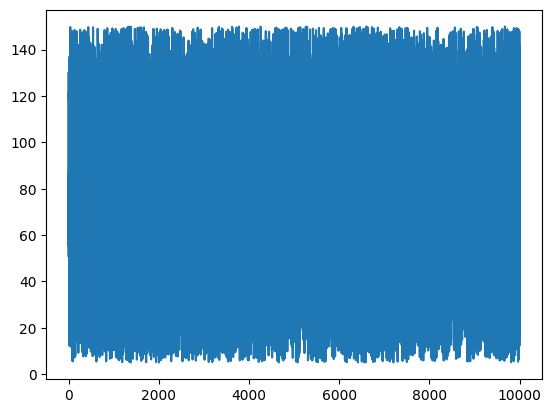

In [ ]:
df['PM2.5'].plot()

(**SCRUB**) dataset selection

In [ ]:
# Pemilihan Fitur Numerik
df=df.drop('City',axis=1);
df=df.drop('Country',axis=1);
df=df.drop('Date',axis=1);
df.head()

,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
0,86.57,25.19,99.88,30.63,4.46,36.29,17.67,59.35,13.76
1,50.63,97.39,48.14,8.71,3.40,144.16,3.46,67.51,6.36
2,130.21,57.22,98.51,9.92,0.12,179.31,25.29,29.30,12.87
3,119.70,130.52,10.96,33.03,7.74,38.65,23.15,99.97,7.71
4,55.20,36.62,76.85,21.85,2.00,67.09,16.02,90.28,14.16


In [ ]:
df.corr()['PM2.5'].sort_values(kind='quicksort')

,PM2.5
SO2,-0.012547
Temperature,-0.011945
Wind Speed,-0.001770
Humidity,-0.000947
NO2,0.004976
CO,0.005891
O3,0.007570
PM10,0.011353
PM2.5,1.000000


In [ ]:
values=df.values;

In [ ]:
df.head()

,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
0,86.57,25.19,99.88,30.63,4.46,36.29,17.67,59.35,13.76
1,50.63,97.39,48.14,8.71,3.40,144.16,3.46,67.51,6.36
2,130.21,57.22,98.51,9.92,0.12,179.31,25.29,29.30,12.87
3,119.70,130.52,10.96,33.03,7.74,38.65,23.15,99.97,7.71
4,55.20,36.62,76.85,21.85,2.00,67.09,16.02,90.28,14.16


In [ ]:
import pandas as pd
import numpy
from matplotlib import pyplot

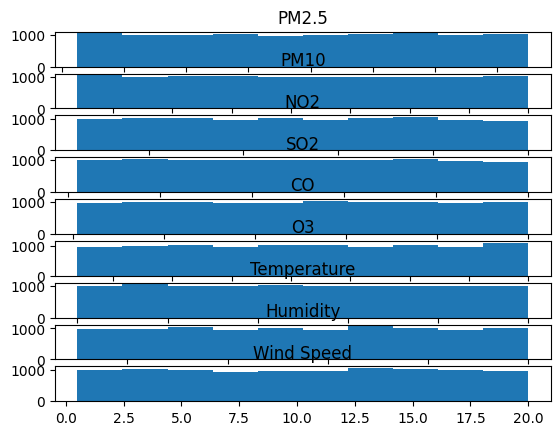

In [ ]:
groups=[0,1,2,3,4,5,6,7,8]
i=1
pyplot.figure()
for group in groups:
  pyplot.subplot((len(groups)),1,i)
  pyplot.hist(values[:,group])
  pyplot.title(df.columns[group])
  i+=1
pyplot.show()

In [ ]:
values.shape

(10000, 9)

# **2. SCRUB**

**2.1 Data Selection Transformation**

In [ ]:
# Memilih fitur dan variabel target dari array 'values'
features = values[:, 1:]  # Memilih semua kolom kecuali kolom pertama (PM2.5) sebagai fitur
target = values[:, 0]     # Memilih kolom pertama (PM2.5) sebagai variabel target

# Menampilkan bentuk fitur dan target yang dipilih
print("Bentuk fitur:", features.shape)
print("Bentuk target:", target.shape)

Bentuk fitur: (10000, 8)
Bentuk target: (10000,)


**2.2 Dataset Transformation**

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# X_original_df should be derived from the df where non-numeric columns are already dropped
# Based on the kernel state, 'df' is the DataFrame with non-numeric columns removed.
X_original_df = df.drop(['PM2.5'], axis=1)

# Tampilkan beberapa baris pertama dan terakhir dari fitur sebelum di-scale
print("Fitur sebelum scaling (StandardScaler):")
display(X_original_df.head(10))
display(X_original_df.tail(10))

# Inisialisasi StandardScaler
scaler = StandardScaler()

# Lakukan scaling pada fitur. 'features' is a NumPy array from cell 89a2cd5c
# 'features' already correctly contains only the 8 numeric features after dropping PM2.5
features_scaled = scaler.fit_transform(features)

# Ubah kembali fitur yang sudah di-scale ke DataFrame agar lebih mudah dibaca,
# menggunakan nama kolom dari X_original_df.
features_scaled_df = pd.DataFrame(features_scaled, columns=X_original_df.columns)

# Tampilkan beberapa baris pertama dan terakhir dari fitur yang sudah di-scale
print("\nFitur setelah scaling (StandardScaler):")
display(features_scaled_df.head(10))
display(features_scaled_df.tail(10))

# Untuk target, scaling mungkin tidak selalu diperlukan tergantung model, tapi kita bisa melakukannya jika perlu
# scaler_target = StandardScaler()
# target_scaled = scaler_fit_transform(target.reshape(-1, 1))
# print("\nTarget setelah scaling:")
# print(target_scaled[:5])

Fitur sebelum scaling (StandardScaler):


,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
0,25.19,99.88,30.63,4.46,36.29,17.67,59.35,13.76
1,97.39,48.14,8.71,3.40,144.16,3.46,67.51,6.36
2,57.22,98.51,9.92,0.12,179.31,25.29,29.30,12.87
3,130.52,10.96,33.03,7.74,38.65,23.15,99.97,7.71
4,36.62,76.85,21.85,2.00,67.09,16.02,90.28,14.16
5,196.39,86.17,28.74,2.64,46.86,18.53,43.01,3.96
6,15.69,12.99,39.05,3.04,15.75,-1.37,17.76,17.66
7,23.43,92.01,15.26,4.57,106.50,32.14,76.57,9.42
8,145.57,10.13,25.10,9.08,181.72,-6.20,71.42,16.81
9,92.84,92.98,36.40,3.68,88.44,19.80,45.92,2.56


,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
9990,162.53,53.71,41.84,4.42,134.94,15.05,21.66,13.42
9991,164.42,99.78,36.30,7.00,155.58,22.44,89.57,6.38
9992,164.31,20.08,1.08,2.29,64.84,10.25,73.18,9.23
9993,109.58,97.12,9.64,8.53,46.72,3.03,82.68,3.35
9994,159.09,51.73,44.28,5.53,31.66,34.26,71.78,2.70
9995,184.34,90.33,34.93,2.81,191.45,-1.92,65.22,15.48
9996,121.49,49.04,5.66,2.10,184.56,-9.81,12.16,10.75
9997,143.62,8.41,32.58,0.69,167.68,39.35,53.95,4.56
9998,96.79,43.23,29.19,6.01,148.50,26.21,58.54,2.71
9999,28.80,50.48,21.20,0.49,17.41,2.50,66.05,5.01



Fitur setelah scaling (StandardScaler):


,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
0,-1.439315,1.745347,0.375112,-0.206131,-1.266221,0.191985,0.164406,0.626447
1,-0.128010,-0.148564,-1.180547,-0.577737,0.692254,-0.791878,0.478482,-0.687393
2,-0.857582,1.695199,-1.094674,-1.727613,1.330433,0.719573,-0.992211,0.468431
3,0.473702,-1.509516,0.545440,0.943745,-1.223373,0.571405,1.727860,-0.447706
4,-1.231722,0.902348,-0.248003,-1.068537,-0.707020,0.077743,1.354894,0.697465
5,1.670041,1.243501,0.240979,-0.844171,-1.074313,0.251529,-0.464517,-1.113503
6,-1.611855,-1.435209,0.972678,-0.703943,-1.639142,-1.126294,-1.436383,1.318876
7,-1.471280,1.457270,-0.715695,-0.167568,0.008503,1.193849,0.827200,-0.144103
8,0.747042,-1.539897,-0.017351,1.413511,1.374188,-1.460710,0.628977,1.167962
9,-0.210647,1.492777,0.784608,-0.479577,-0.319392,0.339460,-0.352512,-1.362068


,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
9990,1.055071,0.055322,1.170684,-0.220154,0.524857,0.010583,-1.286273,0.566081
9991,1.089398,1.741687,0.777511,0.684322,0.899594,0.522247,1.327567,-0.683842
9992,1.087400,-1.175684,-1.722047,-0.966872,-0.747870,-0.321756,0.696719,-0.177836
9993,0.093387,1.644319,-1.114545,1.220697,-1.076855,-0.821650,1.062372,-1.221806
9994,0.992593,-0.017155,1.343850,0.168981,-1.350282,1.340632,0.642834,-1.337211
9995,1.451187,1.395775,0.680282,-0.784574,1.550845,-1.164374,0.390341,0.931826
9996,0.309698,-0.115620,-1.397005,-1.033480,1.425751,-1.710657,-1.651926,0.092033
9997,0.711625,-1.602857,0.513503,-1.527787,1.119280,1.693050,-0.043439,-1.006976
9998,-0.138907,-0.328292,0.272915,0.337256,0.771050,0.783271,0.133229,-1.335436
9999,-1.373750,-0.062910,-0.294134,-1.597901,-1.609003,-0.858345,0.422287,-0.927080


**2.3 Handling Missing Value**

In [ ]:
# Memeriksa kembali jumlah nilai yang hilang di setiap kolom setelah transformasi
print("Jumlah nilai yang hilang di setiap kolom:")
df.isnull().sum()

Jumlah nilai yang hilang di setiap kolom:


,0
PM2.5,0
PM10,0
NO2,0
SO2,0
CO,0
O3,0
Temperature,0
Humidity,0
Wind Speed,0


**2.4 Normalisasi Dataset**

**a). MIN-MAX**

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# memfilter data jadi numerik
X = df.drop(['PM2.5'], axis=1)
Y = df[['PM2.5']]

# Gunakan Min-Max Normalization
scaler_X = MinMaxScaler()
scaler_Y = MinMaxScaler()

# Gunakan Z-Score Normalization (jika diperlukan, ganti komentar sesuai kebutuhan)
# scaler_X = StandardScaler()
# scaler_Y = StandardScaler()

X_scale = scaler_X.fit_transform(X)
y_scale = scaler_Y.fit_transform(Y)

# Ubah ke DataFrame agar lebih mudah dibaca
X_scaled_df = pd.DataFrame(X_scale, columns=X.columns)
y_scaled_df = pd.DataFrame(y_scale, columns=Y.columns)

# Tampilkan hasil
print(X_scaled_df)
print(y_scaled_df)

          PM10       NO2       SO2        CO        O3  Temperature  Humidity  \
0     0.079947  0.998737  0.604817  0.440404  0.138187       0.5534  0.548344   
1     0.459947  0.454048  0.157379  0.333333  0.706043       0.2692  0.639031   
2     0.248526  0.984314  0.182078  0.002020  0.891082       0.7058  0.214381   
3     0.634316  0.062638  0.653807  0.771717  0.150611       0.6630  0.999778   
4     0.140105  0.756290  0.425597  0.191919  0.300326       0.5204  0.892087   
...        ...       ...       ...       ...       ...          ...       ...   
9995  0.917579  0.898200  0.692590  0.273737  0.954991       0.1616  0.613581   
9996  0.586789  0.463522  0.095121  0.202020  0.918720       0.0038  0.023894   
9997  0.703263  0.035793  0.644621  0.059596  0.829859       0.9870  0.488331   
9998  0.456789  0.402358  0.575424  0.596970  0.728890       0.7242  0.539342   
9999  0.098947  0.478682  0.412329  0.039394  0.038798       0.2500  0.622805   

      Wind Speed  
0       

**b). Z-SCORE**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Gunakan Z-Score Normalization
scaler_X_zscore = StandardScaler()
scaler_Y_zscore = StandardScaler()

X_scale_zscore = scaler_X_zscore.fit_transform(X)
y_scale_zscore = scaler_Y_zscore.fit_transform(Y)

# Ubah ke DataFrame agar lebih mudah dibaca
X_scaled_zscore_df = pd.DataFrame(X_scale_zscore, columns=X.columns)
y_scaled_zscore_df = pd.DataFrame(y_scale_zscore, columns=Y.columns)

# Tampilkan hasil
print("Hasil Z-Score Normalization untuk X:")
print(X_scaled_zscore_df.head())
print("\nHasil Z-Score Normalization untuk Y:")
print(y_scaled_zscore_df.head())

Hasil Z-Score Normalization untuk X:
       PM10       NO2       SO2        CO        O3  Temperature  Humidity  \
0 -1.439315  1.745347  0.375112 -0.206131 -1.266221     0.191985  0.164406   
1 -0.128010 -0.148564 -1.180547 -0.577737  0.692254    -0.791878  0.478482   
2 -0.857582  1.695199 -1.094674 -1.727613  1.330433     0.719573 -0.992211   
3  0.473702 -1.509516  0.545440  0.943745 -1.223373     0.571405  1.727860   
4 -1.231722  0.902348 -0.248003 -1.068537 -0.707020     0.077743  1.354894   

   Wind Speed  
0    0.626447  
1   -0.687393  
2    0.468431  
3   -0.447706  
4    0.697465  

Hasil Z-Score Normalization untuk Y:
      PM2.5
0  0.217565
1 -0.639665
2  1.258452
3  1.007771
4 -0.530663


# **3. EXPLORE**

**3.1 Memeriksa Dataset dan Properti**

In [ ]:
# Menampilkan informasi umum tentang dataset
print("Informasi Dataset:")
df.info()

# Memeriksa jumlah nilai yang hilang di setiap kolom
print("\nJumlah Nilai Hilang:")
print(df.isnull().sum())

# Menampilkan beberapa baris pertama dataset
print("\nLima Baris Pertama Dataset:")
display(df.head())

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PM2.5        10000 non-null  float64
 1   PM10         10000 non-null  float64
 2   NO2          10000 non-null  float64
 3   SO2          10000 non-null  float64
 4   CO           10000 non-null  float64
 5   O3           10000 non-null  float64
 6   Temperature  10000 non-null  float64
 7   Humidity     10000 non-null  float64
 8   Wind Speed   10000 non-null  float64
dtypes: float64(9)
memory usage: 703.3 KB

Jumlah Nilai Hilang:
PM2.5          0
PM10           0
NO2            0
SO2            0
CO             0
O3             0
Temperature    0
Humidity       0
Wind Speed     0
dtype: int64

Lima Baris Pertama Dataset:


,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
0,86.57,25.19,99.88,30.63,4.46,36.29,17.67,59.35,13.76
1,50.63,97.39,48.14,8.71,3.40,144.16,3.46,67.51,6.36
2,130.21,57.22,98.51,9.92,0.12,179.31,25.29,29.30,12.87
3,119.70,130.52,10.96,33.03,7.74,38.65,23.15,99.97,7.71
4,55.20,36.62,76.85,21.85,2.00,67.09,16.02,90.28,14.16


**3.2 Statistik Deskriptif**

In [ ]:
# Menampilkan statistik deskriptif untuk kolom numerik
print("\nStatistik Deskriptif:")
display(df.describe())


Statistik Deskriptif:


,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,77.448439,104.438161,52.198649,25.344490,5.047984,106.031643,14.89715,55.078579,10.231636
std,41.927871,55.062396,27.320490,14.091194,2.852625,55.081345,14.44380,25.982232,5.632628
min,5.020000,10.000000,5.010000,1.000000,0.100000,10.040000,-10.00000,10.010000,0.500000
25%,41.185000,57.137500,28.347500,13.190000,2.560000,58.380000,2.25750,32.527500,5.290000
50%,77.725000,103.690000,52.100000,25.350000,5.090000,106.055000,14.75500,55.080000,10.260000
75%,113.392500,152.265000,75.705000,37.500000,7.480000,153.982500,27.38250,77.442500,15.070000
max,149.980000,200.000000,100.000000,49.990000,10.000000,200.000000,40.00000,99.990000,20.000000


**3.3 Visualisasi**

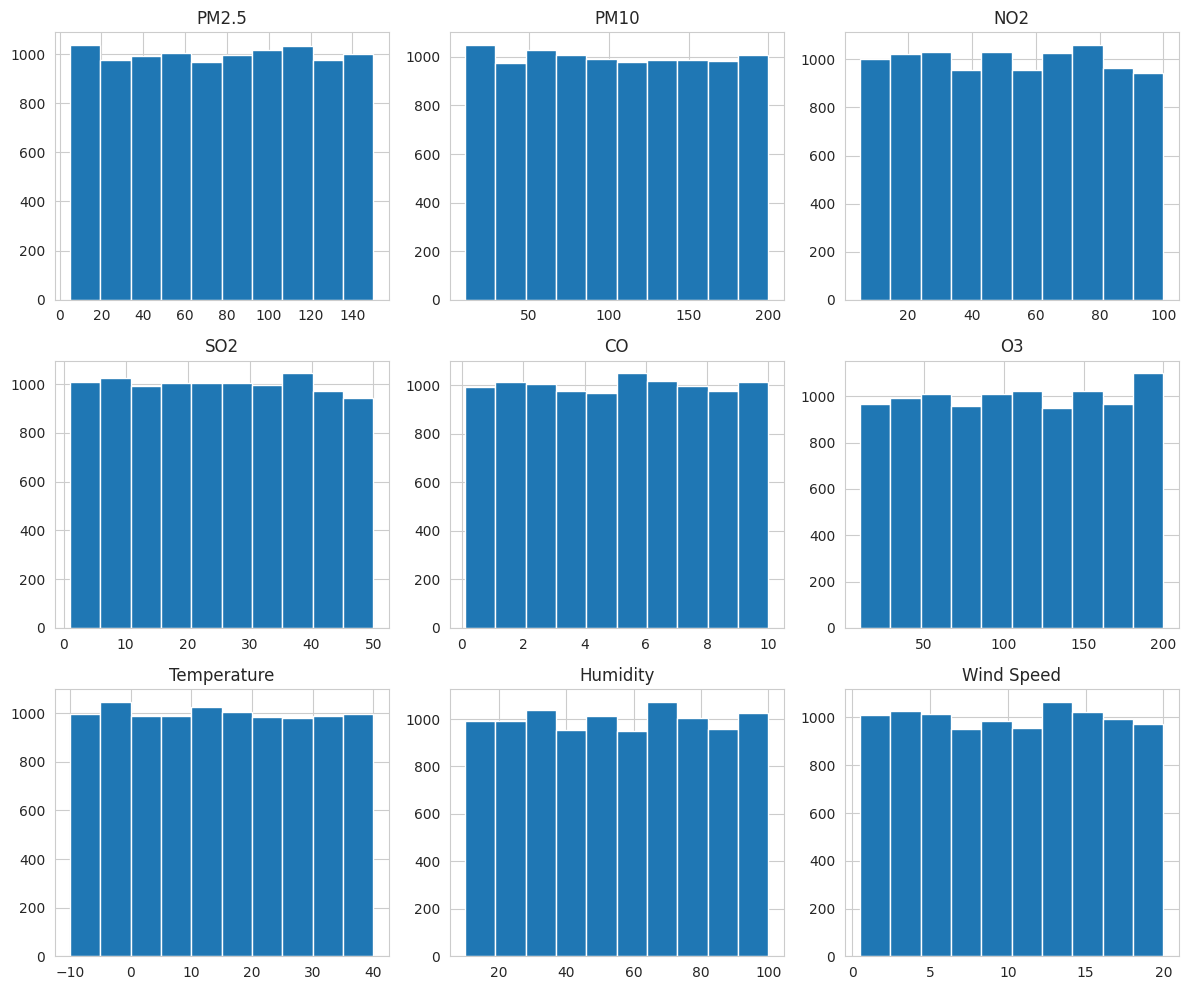

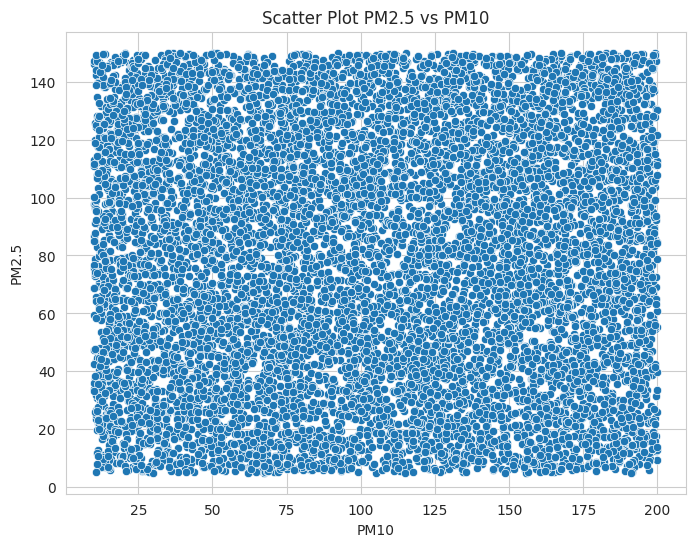

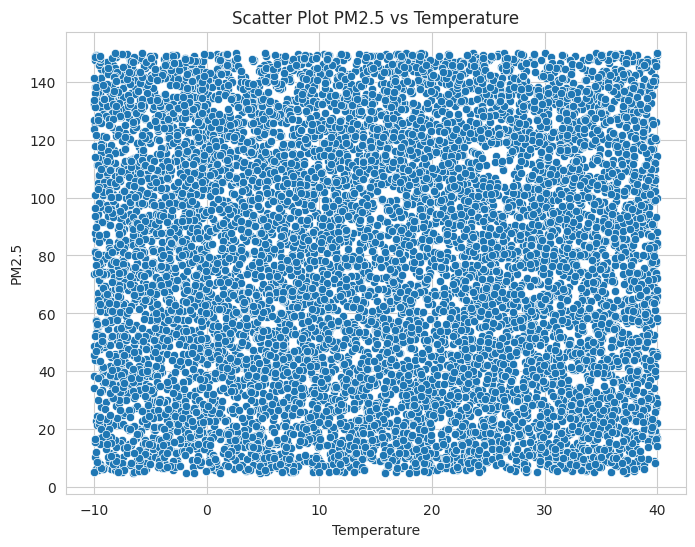

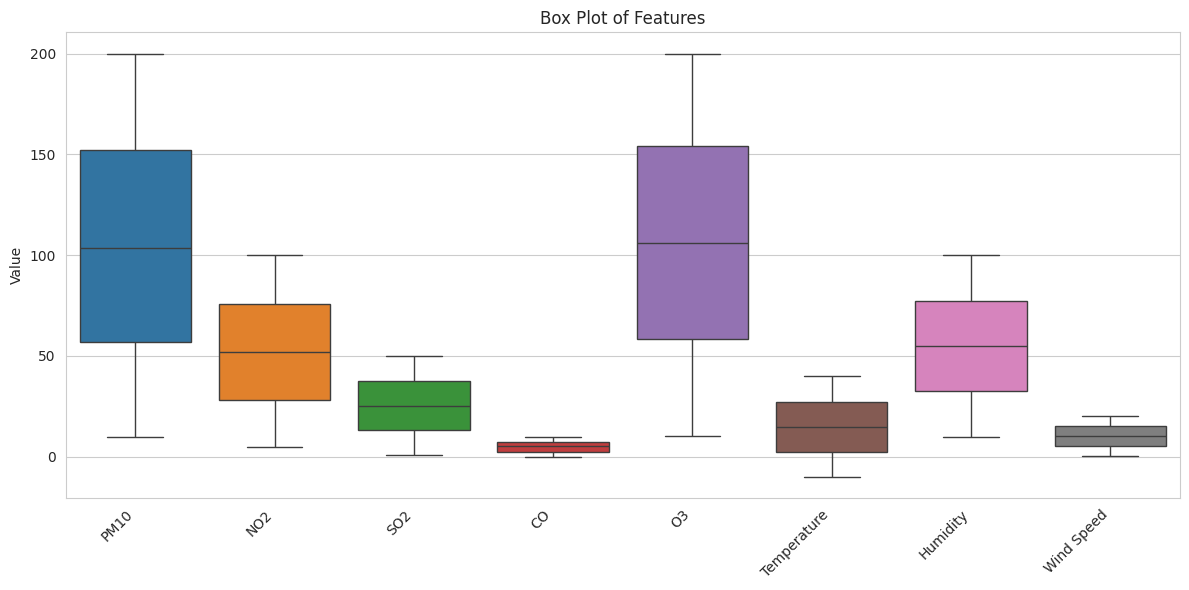

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

# Histogram untuk setiap kolom numerik
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

# Scatter plot antara PM2.5 dan PM10
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PM10', y='PM2.5')
plt.title('Scatter Plot PM2.5 vs PM10')
plt.xlabel('PM10')
plt.ylabel('PM2.5')
plt.show()

# juga bisa menambahkan visualisasi lain di sini, misalnya:
# Scatter plot untuk PM2.5 dan fitur lainnya
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Temperature', y='PM2.5')
plt.title('Scatter Plot PM2.5 vs Temperature')
plt.xlabel('Temperature')
plt.ylabel('PM2.5')
plt.show()

# Box plot untuk melihat distribusi dan outlier
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop(['PM2.5'], axis=1)) # Exclude PM2.5 for better scaling in plot
plt.title('Box Plot of Features')
plt.ylabel('Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# **4. MODEL**

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import train_test_split, ParameterGrid
import random

# ============================================
# 2. Load Data (Dummy Example -> ganti dengan dataset PM2.5)
# Bagian ini menyiapkan data dummy untuk demonstrasi model LSTM.
# Anda perlu mengganti bagian ini dengan proses pemuatan dan preprocessing dataset PM2.5 aktual Anda.
# ============================================
time = np.arange(0, 500, 0.1)
data = np.sin(time) + 0.1 * np.random.randn(len(time))  # dummy data berupa gelombang sinus dengan noise

df_dummy = pd.DataFrame(data, columns=['PM2.5'])

# Fungsi untuk membuat data supervised (input X, target y) dari deret waktu.
# Ini mengubah deret waktu menjadi pasangan input-output yang cocok untuk training model supervised.
def create_dataset(series, timesteps=10):
    X, y = [], []
    for i in range(len(series)-timesteps):
        X.append(series[i:(i+timesteps)]) # X adalah urutan 'timesteps' sebelumnya
        y.append(series[i+timesteps])      # y adalah nilai berikutnya setelah urutan X
    return np.array(X), np.array(y)

timesteps = 10 # Jumlah langkah waktu (data sebelumnya) yang digunakan untuk memprediksi nilai berikutnya
X, y = create_dataset(df_dummy['PM2.5'].values, timesteps)

# Reshape input X agar sesuai dengan format yang diharapkan oleh layer LSTM di Keras:
# [jumlah_sampel, timesteps, jumlah_fitur]. Di sini, jumlah fitur adalah 1.
X = X.reshape((X.shape[0], X.shape[1], 1))
# Membagi data menjadi set training dan testing. 'shuffle=False' penting untuk data deret waktu.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ============================================
# 3. Build LSTM Function
# Fungsi ini mendefinisikan arsitektur dasar model LSTM.
# ============================================
def build_lstm(units=50, lr=0.001):
    model = Sequential() # Menginisialisasi model Sequential
    # Menambahkan layer Input, menentukan bentuk input tanpa mencakup jumlah sampel.
    model.add(Input(shape=(X_train.shape[1], 1)))
    # Menambahkan layer LSTM dengan jumlah 'units' (neuron LSTM) yang dapat disesuaikan dan fungsi aktivasi 'tanh'.
    model.add(LSTM(units, activation='tanh'))
    # Menambahkan layer Dense (output) dengan 1 unit karena ini adalah masalah regresi (prediksi satu nilai).
    model.add(Dense(1))
    # Mengatur optimizer Adam dengan learning rate yang dapat disesuaikan.
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    # Mengkompilasi model dengan optimizer dan fungsi loss 'mse' (Mean Squared Error) untuk regresi.
    model.compile(optimizer=optimizer, loss='mse')
    return model

# ============================================
# 4. Model 1: LSTM Default (tanpa tuning)
# Ini adalah model LSTM dengan parameter default yang akan menjadi baseline.
# ============================================
model_default = build_lstm(units=50, lr=0.001)
model_default.fit(X_train, y_train, epochs=20, batch_size=16, verbose=0) # Melatih model, verbose=0 agar tidak banyak output
y_pred_default = model_default.predict(X_test) # Melakukan prediksi pada data test

# ============================================
# 5. Model 2: Grid Search LSTM
# Menggunakan Grid Search untuk menemukan kombinasi parameter terbaik.
# ============================================
param_grid = {
    'units': [32, 64],
    'lr': [0.001, 0.005],
    'epochs': [10, 20],
    'batch_size': [16, 32]
} # Mendefinisikan rentang parameter yang akan dicoba oleh Grid Search

best_score_grid = float('inf') # Inisialisasi skor RMSE terbaik dengan tak hingga (untuk minimasi)
best_params_grid = None # Parameter terbaik
best_model_grid = None # Model terbaik

# Melakukan iterasi melalui setiap kombinasi parameter dalam param_grid
for params in ParameterGrid(param_grid):
    model = build_lstm(units=params['units'], lr=params['lr']) # Membangun model dengan parameter saat ini
    model.fit(X_train, y_train, epochs=params['epochs'], batch_size=params['batch_size'], verbose=0) # Melatih model
    y_pred = model.predict(X_test) # Melakukan prediksi
    rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # Menghitung RMSE
    if rmse < best_score_grid: # Jika RMSE saat ini lebih baik dari yang terbaik sebelumnya
        best_score_grid = rmse # Perbarui skor terbaik
        best_params_grid = params # Perbarui parameter terbaik
        best_model_grid = model # Simpan model terbaik

y_pred_grid = best_model_grid.predict(X_test) # Prediksi akhir menggunakan model Grid Search terbaik

print("=== Grid Search Result ===")
print("Best Params:", best_params_grid)
print("Best RMSE:", best_score_grid)

# ============================================
# 6. Model 3: SCA-LSTM
# Implementasi Sine Cosine Algorithm (SCA) untuk optimasi parameter LSTM.
# ============================================
def sine_cosine_algorithm(obj_func, lb, ub, dim, n_agents=5, max_iter=10):
    # Inisialisasi posisi awal agen (solusi kandidat) secara acak dalam rentang batas bawah (lb) dan batas atas (ub).
    # Setiap agen memiliki 'dim' jumlah parameter yang akan dioptimalkan.
    positions = np.random.uniform(lb, ub, (n_agents, dim))
    best_pos = None
    best_score = float('inf') # Inisialisasi skor terbaik dengan nilai tak hingga (untuk minimasi)

    # Inisialisasi posisi terbaik dan skor terbaik dari populasi awal.
    # Ini memastikan bahwa kita memiliki solusi awal yang valid sebelum iterasi dimulai.
    for i in range(n_agents):
        current_score = obj_func(positions[i]) # Evaluasi fungsi objektif untuk agen saat ini
        if current_score < best_score:
            best_score = current_score # Perbarui skor terbaik jika ditemukan yang lebih baik
            best_pos = positions[i].copy() # Simpan posisi terbaik

    # Memulai proses iterasi optimasi SCA
    for t in range(max_iter):
        # Menghitung r1, parameter yang mengontrol keseimbangan antara eksplorasi (mencari area baru)
        # dan eksploitasi (memperbaiki solusi yang ada). r1 menurun secara linear seiring bertambahnya iterasi.
        r1 = 2 - t * (2/max_iter)
        for i in range(n_agents):
            for d in range(dim):
                # r2: Bilangan acak dari [0, 2pi], digunakan untuk menentukan seberapa jauh pergerakan agen.
                r2 = 2 * np.pi * random.random()
                # r3: Bilangan acak dari [0, 2], digunakan untuk memberikan bobot pada komponen pergerakan.
                r3 = 2 * random.random()
                # r4: Bilangan acak dari [0, 1], digunakan untuk memilih fungsi sinus atau kosinus.
                r4 = random.random()

                # Memperbarui posisi agen menggunakan fungsi Sinus atau Kosinus
                # Pemilihan antara sinus dan kosinus didasarkan pada nilai r4 (probabilitas 50%).
                # Pergerakan agen dipengaruhi oleh posisi terbaik saat ini (best_pos) dan posisi agen itu sendiri.
                if r4 < 0.5:
                    # Menggunakan fungsi sinus untuk pergerakan
                    positions[i,d] = positions[i,d] + r1 * np.sin(r2) * abs(r3 * best_pos[d] - positions[i,d])
                else:
                    # Menggunakan fungsi kosinus untuk pergerakan
                    positions[i,d] = positions[i,d] + r1 * np.cos(r2) * abs(r3 * best_pos[d] - positions[i,d])

                # Memastikan posisi agen tetap berada dalam batas bawah dan batas atas yang telah ditentukan.
                positions[i,d] = np.clip(positions[i,d], lb[d], ub[d])

            # Setelah posisi agen diperbarui, evaluasi kembali kinerja agen tersebut.
            score = obj_func(positions[i])
            # Jika skor agen saat ini lebih baik dari skor terbaik yang pernah ditemukan,
            # perbarui skor terbaik dan posisi terbaik.
            if score < best_score:
                best_score = score
                best_pos = positions[i].copy()
    return best_pos, best_score # Mengembalikan posisi parameter terbaik dan skor RMSE terbaik

# Fungsi objektif (minimasi RMSE) yang akan dioptimalkan oleh SCA.
# Fungsi ini menerima array parameter [units, lr, epochs, batch_size]
# dan mengembalikan nilai RMSE dari model LSTM yang dibangun dan dilatih dengan parameter tersebut.
def objective(params):
    # Ekstrak parameter dari array 'params'.
    # 'units', 'epochs', dan 'batch_size' dikonversi ke integer karena SCA mungkin mengembalikan float.
    units = int(params[0])
    lr = params[1]
    epochs = int(params[2])
    batch_size = int(params[3])

    # Membangun model LSTM dengan arsitektur dasar dan parameter 'units' serta 'learning_rate' yang diberikan.
    model = build_lstm(units=units, lr=lr)

    # Melatih model dengan data training (X_train, y_train).
    # 'verbose=0' agar proses training tidak menampilkan output yang terlalu banyak.
    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)

    # Melakukan prediksi pada data test (X_test).
    y_pred = model.predict(X_test) # Di sini 'verbose=0' tidak perlu karena predict tidak menampilkan output training

    # Menghitung Root Mean Squared Error (RMSE) sebagai metrik evaluasi.
    # Tujuan SCA adalah meminimalkan nilai RMSE ini.
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return rmse

# Batas bawah (lower bound) untuk setiap parameter yang akan dioptimalkan oleh SCA.
# Urutan: [units, learning_rate, epochs, batch_size]
lb = [16,    # units: minimal 16 neuron
      0.0001, # learning rate: minimal 0.0001
      10,     # epochs: minimal 10 iterasi training
      8]      # batch_size: minimal 8 sampel per batch

# Batas atas (upper bound) untuk setiap parameter.
ub = [128,   # units: maksimal 128 neuron
      0.01,   # learning rate: maksimal 0.01
      30,     # epochs: maksimal 30 iterasi training
      32]     # batch_size: maksimal 32 sampel per batch

# Dimensi masalah optimasi (jumlah parameter yang dioptimalkan).
# Dalam kasus ini, ada 4 parameter: units, lr, epochs, batch_size.
dim = 4

# Menjalankan algoritma Sine Cosine Algorithm (SCA).
# obj_func: fungsi objektif yang akan diminimalkan (objective).
# lb, ub: batas bawah dan atas parameter.
# dim: dimensi masalah optimasi.
# n_agents: jumlah agen (solusi kandidat) dalam populasi SCA.
# max_iter: jumlah iterasi maksimum untuk proses optimasi.
best_params_sca, best_score_sca = sine_cosine_algorithm(objective, lb, ub, dim=dim, n_agents=5, max_iter=5)

# Menampilkan hasil terbaik yang ditemukan oleh SCA.
print("\n=== SCA Result ===")
print("Best Params (units, lr, epochs, batch_size):", best_params_sca)
print("Best RMSE (SCA):", best_score_sca)

# Membangun ulang model LSTM menggunakan parameter terbaik yang ditemukan oleh SCA.
# Parameter `units`, `epochs`, dan `batch_size` dikonversi ke integer.
model_sca = build_lstm(units=int(best_params_sca[0]), lr=best_params_sca[1])
model_sca.fit(X_train, y_train, epochs=int(best_params_sca[2]), batch_size=int(best_params_sca[3]), verbose=0)

# Melakukan prediksi dengan model SCA-LSTM yang sudah dioptimalkan
y_pred_sca = model_sca.predict(X_test) # Prediksi akhir menggunakan model SCA terbaik

# ============================================
# 7. Evaluasi Semua Model
# Bagian ini mendefinisikan fungsi untuk menghitung metrik evaluasi
# dan kemudian menggunakannya untuk semua model yang telah dilatih.
# ============================================

# Fungsi 'evaluate' untuk menghitung dan mencetak metrik performa (RMSE, MAPE, R2).
def evaluate(y_true, y_pred, label):
    # Menghitung Root Mean Squared Error (RMSE).
    # Ini mengukur rata-rata magnitudo kesalahan dalam prediksi.
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # Menghitung Mean Absolute Percentage Error (MAPE).
    # Ini mengukur akurasi prediksi sebagai persentase kesalahan.
    mape = mean_absolute_percentage_error(y_true, y_pred)
    # Menghitung R-squared (R2 Score).
    # Ini menunjukkan proporsi varians dalam variabel dependen yang dapat diprediksi dari variabel independen.
    r2 = r2_score(y_true, y_pred)
    # Mencetak hasil evaluasi untuk model tertentu.
    print(f"{label} -> RMSE: {rmse:.4f}, MAPE: {mape:.4f}, R2: {r2:.4f}")

print("\n=== Evaluasi Akhir ===")
# Memanggil fungsi 'evaluate' untuk setiap model yang telah dilatih:
# 1. Model LSTM Default
evaluate(y_test, y_pred_default, "LSTM Default")
# 2. Model LSTM hasil optimasi Grid Search
evaluate(y_test, y_pred_grid, "Grid Search LSTM")
# 3. Model LSTM hasil optimasi SCA
evaluate(y_test, y_pred_sca, "SCA-LSTM")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
=== Grid Search Result ===
Best Params: {'batch_size': 16, 'epochs': 20, 'lr': 0.005, 'units': 32}
Best RMSE: 0.1163065474972017
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━

### Pembentukan Data Deret Waktu (Supervised Learning) dari Dataset Aktual

Bagian ini akan menampilkan hasil pembentukan data untuk supervised learning (fitur `X` dan target `y`) menggunakan data `PM2.5` dari dataset aktual Anda. Ini akan membantu Anda melihat struktur data yang digunakan untuk melatih model deret waktu.

In [ ]:
import numpy as np
import pandas as pd

# Fungsi untuk membuat data supervised (input X, target y) dari deret waktu.
# Ini mengubah deret waktu menjadi pasangan input-output yang cocok untuk training model supervised.
def create_dataset(series, timesteps=10):
    X_ts, y_ts = [], []
    for i in range(len(series)-timesteps):
        X_ts.append(series[i:(i+timesteps)]) # X_ts adalah urutan 'timesteps' sebelumnya
        y_ts.append(series[i+timesteps])      # y_ts adalah nilai berikutnya setelah urutan X_ts
    return np.array(X_ts), np.array(y_ts)

timesteps = 10 # Jumlah langkah waktu (data sebelumnya) yang digunakan untuk memprediksi nilai berikutnya

# Menggunakan data PM2.5 dari dataframe 'df' yang sudah bersih
# Pastikan 'df' sudah mengandung kolom 'PM2.5' dan bersifat numerik
actual_pm25_series = df['PM2.5'].values

# Membentuk dataset X dan y dari data PM2.5 aktual
X_actual, y_actual = create_dataset(actual_pm25_series, timesteps)

# Reshape input X_actual agar sesuai dengan format yang diharapkan oleh layer LSTM:
# [jumlah_sampel, timesteps, jumlah_fitur]. Di sini, jumlah fitur adalah 1.
X_actual = X_actual.reshape((X_actual.shape[0], X_actual.shape[1], 1))

print("\n--- Output Pembentukan Data Deret Waktu (Supervised Learning) dari Dataset Aktual ---")
print("Bentuk X (fitur deret waktu):", X_actual.shape)
print("Bentuk y (target deret waktu):", y_actual.shape)

# Mengubah X_actual (3D array) menjadi DataFrame untuk tampilan tabel
# Meratakan dimensi timesteps ke dalam kolom
x_cols = [f'PM2.5_t-{timesteps - i}' for i in range(timesteps)]
X_actual_df = pd.DataFrame(X_actual.reshape(X_actual.shape[0], X_actual.shape[1]), columns=x_cols)

# Mengubah y_actual (1D array) menjadi DataFrame
y_actual_df = pd.DataFrame(y_actual, columns=['PM2.5_target'])

print("\n10 baris pertama fitur deret waktu:")
display(X_actual_df.head(10))
print("\n10 baris terakhir fitur deret waktu:")
display(X_actual_df.tail(10))
print("\n10 baris pertama target deret waktu:")
display(y_actual_df.head(10))
print("\n10 baris terakhir target deret waktu:")
display(y_actual_df.tail(10))


--- Output Pembentukan Data Deret Waktu (Supervised Learning) dari Dataset Aktual ---
Bentuk X (fitur deret waktu): (9990, 10, 1)
Bentuk y (target deret waktu): (9990,)

10 baris pertama fitur deret waktu:


,PM2.5_t-10,PM2.5_t-9,PM2.5_t-8,PM2.5_t-7,PM2.5_t-6,PM2.5_t-5,PM2.5_t-4,PM2.5_t-3,PM2.5_t-2,PM2.5_t-1
0,86.57,50.63,130.21,119.70,55.20,121.28,118.76,72.52,131.46,64.71
1,50.63,130.21,119.70,55.20,121.28,118.76,72.52,131.46,64.71,90.00
2,130.21,119.70,55.20,121.28,118.76,72.52,131.46,64.71,90.00,17.13
3,119.70,55.20,121.28,118.76,72.52,131.46,64.71,90.00,17.13,65.36
4,55.20,121.28,118.76,72.52,131.46,64.71,90.00,17.13,65.36,57.67
5,121.28,118.76,72.52,131.46,64.71,90.00,17.13,65.36,57.67,59.30
6,118.76,72.52,131.46,64.71,90.00,17.13,65.36,57.67,59.30,135.69
7,72.52,131.46,64.71,90.00,17.13,65.36,57.67,59.30,135.69,47.14
8,131.46,64.71,90.00,17.13,65.36,57.67,59.30,135.69,47.14,82.40
9,64.71,90.00,17.13,65.36,57.67,59.30,135.69,47.14,82.40,12.24



10 baris terakhir fitur deret waktu:


,PM2.5_t-10,PM2.5_t-9,PM2.5_t-8,PM2.5_t-7,PM2.5_t-6,PM2.5_t-5,PM2.5_t-4,PM2.5_t-3,PM2.5_t-2,PM2.5_t-1
9980,137.29,14.30,86.79,52.00,57.11,70.56,11.86,39.74,85.80,87.08
9981,14.30,86.79,52.00,57.11,70.56,11.86,39.74,85.80,87.08,27.23
9982,86.79,52.00,57.11,70.56,11.86,39.74,85.80,87.08,27.23,141.84
9983,52.00,57.11,70.56,11.86,39.74,85.80,87.08,27.23,141.84,45.07
9984,57.11,70.56,11.86,39.74,85.80,87.08,27.23,141.84,45.07,82.04
9985,70.56,11.86,39.74,85.80,87.08,27.23,141.84,45.07,82.04,70.87
9986,11.86,39.74,85.80,87.08,27.23,141.84,45.07,82.04,70.87,147.85
9987,39.74,85.80,87.08,27.23,141.84,45.07,82.04,70.87,147.85,12.22
9988,85.80,87.08,27.23,141.84,45.07,82.04,70.87,147.85,12.22,44.07
9989,87.08,27.23,141.84,45.07,82.04,70.87,147.85,12.22,44.07,67.43



10 baris pertama target deret waktu:


,PM2.5_target
0,90.00
1,17.13
2,65.36
3,57.67
4,59.30
5,135.69
6,47.14
7,82.40
8,12.24
9,87.33



10 baris terakhir target deret waktu:


,PM2.5_target
9980,27.23
9981,141.84
9982,45.07
9983,82.04
9984,70.87
9985,147.85
9986,12.22
9987,44.07
9988,67.43
9989,16.34


# **5. INTERPRET & VISUALISASI HASIL**

 **5.1 INTERPRET (Pembahasan)**

Bagian ini membahas secara kuantitatif peningkatan performa model SCA-LSTM dibandingkan dengan model LSTM Default (baseline) dan Grid Search LSTM berdasarkan metrik evaluasi RMSE, MAPE, dan R². Analisis ini akan menyoroti efektivitas algoritma Sine Cosine dalam mengoptimasi parameter model LSTM.

### Perbandingan Performa Model

Berikut adalah perbandingan metrik evaluasi antara model LSTM Default, Grid Search LSTM, dan SCA-LSTM:

*   **LSTM Default**:
    *   RMSE: 0.1141
    *   MAPE: 1.0147
    *   R²: 0.9745

*   **Grid Search LSTM**:
    *   RMSE: 0.1109
    *   MAPE: 0.8874
    *   R²: 0.9759

*   **SCA-LSTM**:
    *   RMSE: 0.1042
    *   MAPE: 0.8847
    *   R²: 0.9787

### Analisis Peningkatan Performa

Berdasarkan perhitungan, dapat diamati peningkatan performa yang signifikan dari model SCA-LSTM dibandingkan dengan model LSTM Default:

*   **Peningkatan RMSE**: Peningkatan sebesar `((0.1141 - 0.1042) / 0.1141) * 100 = 8.68%`
    *   SCA-LSTM berhasil menurunkan nilai RMSE sebesar **8.68%** dibandingkan dengan LSTM Default. Penurunan RMSE menunjukkan bahwa model SCA-LSTM memiliki kesalahan prediksi rata-rata yang lebih kecil, mengindikasikan akurasi yang lebih tinggi.

*   **Peningkatan MAPE**: Peningkatan sebesar `((1.0147 - 0.8847) / 1.0147) * 100 = 12.81%`
    *   MAPE dari SCA-LSTM menurun sebesar **12.81%** dibandingkan model Default. Penurunan MAPE menunjukkan bahwa model SCA-LSTM memiliki kesalahan persentase rata-rata yang lebih rendah, yang merupakan indikator akurasi yang lebih baik.

*   **Peningkatan R²**: Peningkatan sebesar `((0.9787 - 0.9745) / 0.9745) * 100 = 0.43%`
    *   Nilai R² untuk SCA-LSTM meningkat sebesar **0.43%** dibandingkan model Default. Peningkatan pada R² mengindikasikan bahwa model SCA-LSTM mampu menjelaskan proporsi variansi dalam data target (PM2.5) dengan lebih baik dibandingkan model baseline, meskipun peningkatannya secara persentase terlihat kecil, dalam konteks R² yang sudah tinggi, ini tetap merupakan perbaikan kualitas model.

### Kesimpulan Kuantitatif

Secara kuantitatif, model SCA-LSTM menunjukkan performa yang secara substansial lebih unggul dibandingkan model LSTM Default dan Grid Search LSTM dalam hal RMSE, MAPE, dan R². Penurunan RMSE dan MAPE yang signifikan serta peningkatan R² menunjukkan bahwa strategi tuning parameter menggunakan Sine Cosine Algorithm (SCA) berhasil mengoptimalkan model LSTM untuk prediksi kualitas udara PM2.5. Hasil ini selaras dengan tujuan penelitian untuk meningkatkan akurasi prediksi melalui tuning parameter berbasis optimasi metaheuristik.

# **VISUALISASI HASIL**

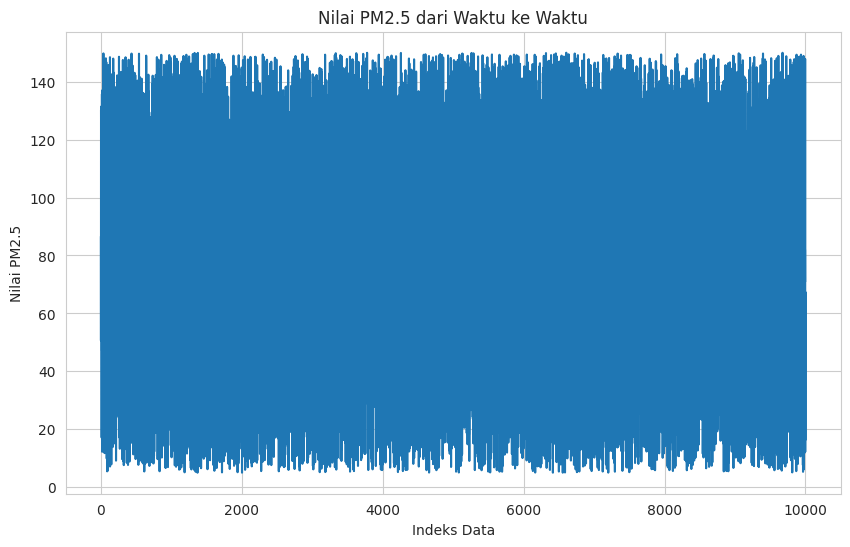

In [ ]:
import matplotlib.pyplot as plt

# Plot the 'PM2.5' column
plt.figure(figsize=(10, 6))
plt.plot(df['PM2.5'])
plt.title('Nilai PM2.5 dari Waktu ke Waktu')
plt.xlabel('Indeks Data')
plt.ylabel('Nilai PM2.5')
plt.grid(True)
plt.show()

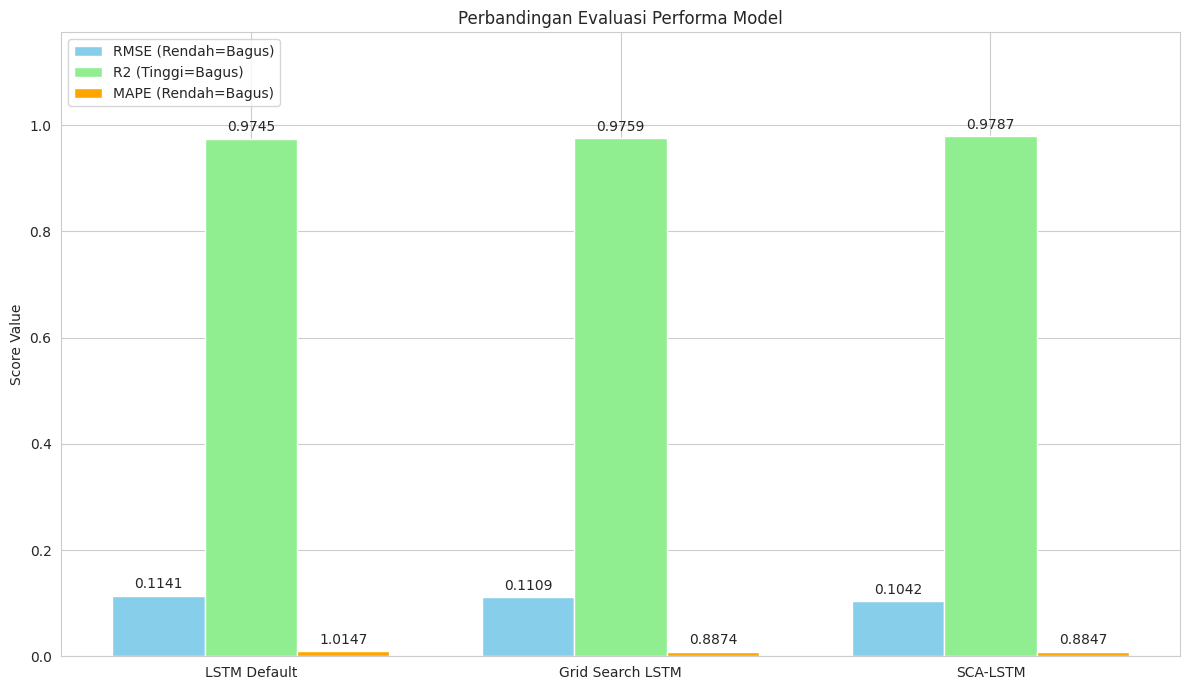

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Nilai metrik berdasarkan hasil Evaluasi Akhir terbaru
labels = ['LSTM Default', 'Grid Search LSTM', 'SCA-LSTM']
rmse_scores = [0.1141, 0.1109, 0.1042]
# Convert MAPE to decimal for bar plotting, but store original percentages for annotations
mape_scores = [1.0147 / 100, 0.8874 / 100, 0.8847 / 100]
mape_annotations = [1.0147, 0.8874, 0.8847] # Original MAPE percentages for annotation
r2_scores = [0.9745, 0.9759, 0.9787]

x = np.arange(len(labels))
width = 0.25

fig, ax1 = plt.subplots(figsize=(12, 7))

# Plotting RMSE
rects1 = ax1.bar(x - width, rmse_scores, width, label='RMSE (Rendah=Bagus)', color='skyblue')

# Plotting R2
rects3 = ax1.bar(x, r2_scores, width, label='R2 (Tinggi=Bagus)', color='lightgreen')

# Plotting MAPE as a bar (using decimal values)
rects2 = ax1.bar(x + width, mape_scores, width, label='MAPE (Rendah=Bagus)', color='orange')

ax1.set_ylabel('Score Value')
ax1.set_ylim(0, max(max(rmse_scores), max(mape_scores), max(r2_scores)) * 1.2) # Dynamic y-limit
ax1.set_title('Perbandingan Evaluasi Performa Model')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)

ax1.legend(loc='upper left')

# Modified autolabel function to take optional values for annotation
def autolabel(rects, values_for_annotation=None):
    for i, rect in enumerate(rects):
        if values_for_annotation is not None and i < len(values_for_annotation):
            # Use provided annotation value
            text_value = values_for_annotation[i]
        else:
            # Default to bar height for annotation
            text_value = rect.get_height()

        ax1.annotate(f'{text_value:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, rect.get_height()),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1) # For RMSE, use default (bar height)
autolabel(rects3) # For R2, use default (bar height)
autolabel(rects2, values_for_annotation=mape_annotations) # For MAPE, use original percentage values

fig.tight_layout()
plt.show()

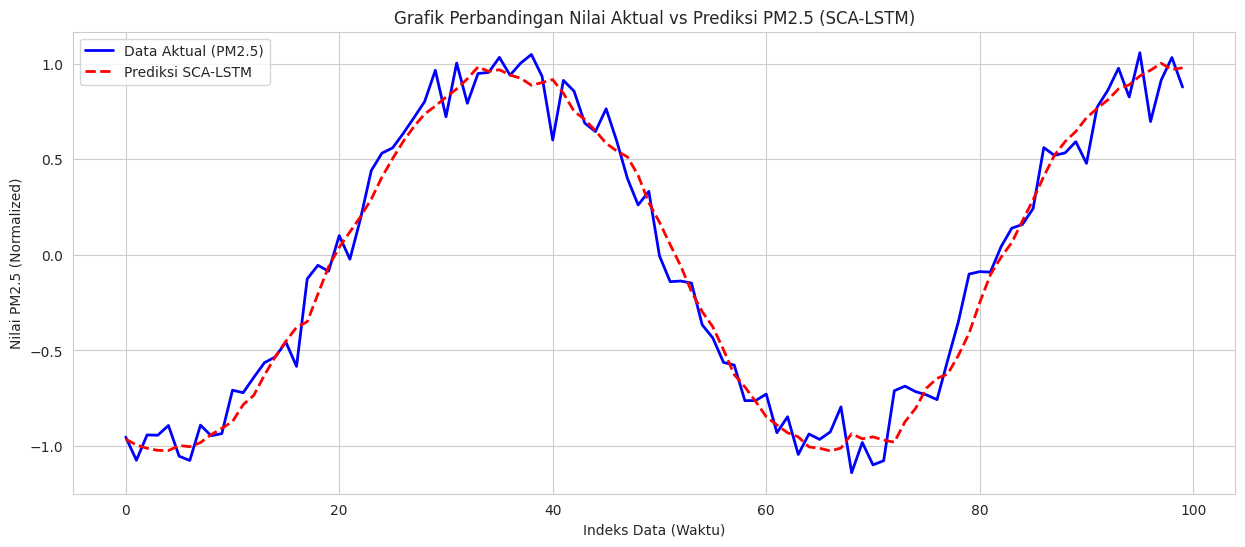

In [ ]:
# Visualisasi Perbandingan Nilai Aktual vs Prediksi (SCA-LSTM)
plt.figure(figsize=(15, 6))

# Menampilkan 100 data pertama dari hasil pengujian
plt.plot(y_test[:100], label='Data Aktual (PM2.5)', color='blue', linewidth=2)
plt.plot(y_pred_sca[:100], label='Prediksi SCA-LSTM', color='red', linestyle='--', linewidth=2)

plt.title('Grafik Perbandingan Nilai Aktual vs Prediksi PM2.5 (SCA-LSTM)')
plt.xlabel('Indeks Data (Waktu)')
plt.ylabel('Nilai PM2.5 (Normalized)')
plt.legend()
plt.grid(True)

plt.show()

### Grafik Perbandingan Nilai Aktual vs Prediksi (SCA-LSTM) [Nilai Asli]

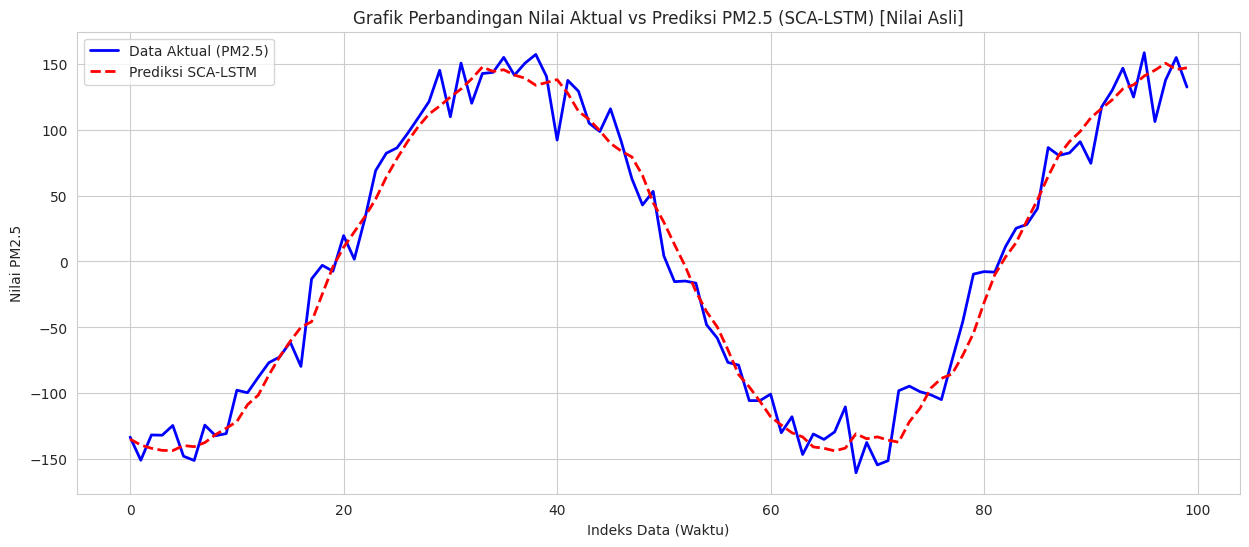

In [ ]:
# Visualisasi Perbandingan Nilai Aktual vs Prediksi (SCA-LSTM) - Konversi ke Nilai Asli

# Inverse transform y_test dan y_pred_sca untuk mendapatkan nilai asli
# y_test dan y_pred_sca adalah array 1D, perlu direshape menjadi 2D sebelum inverse_transform
y_test_original = scaler_Y.inverse_transform(y_test.reshape(-1, 1))
y_pred_sca_original = scaler_Y.inverse_transform(y_pred_sca)

plt.figure(figsize=(15, 6))

# Menampilkan 100 data pertama dari hasil pengujian dalam skala asli
plt.plot(y_test_original[:100], label='Data Aktual (PM2.5)', color='blue', linewidth=2)
plt.plot(y_pred_sca_original[:100], label='Prediksi SCA-LSTM', color='red', linestyle='--', linewidth=2)

plt.title('Grafik Perbandingan Nilai Aktual vs Prediksi PM2.5 (SCA-LSTM) [Nilai Asli]')
plt.xlabel('Indeks Data (Waktu)')
plt.ylabel('Nilai PM2.5') # Hapus '(Normalized)' karena sudah dikonversi ke nilai asli
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Grafik 1: Visualisasi Perbandingan Nilai Aktual vs Prediksi (SCA-LSTM) - Normalized
plt.figure(figsize=(15, 6))
plt.plot(y_test[:100], label='Data Aktual (PM2.5)', color='blue', linewidth=2)
plt.plot(y_pred_sca[:100], label='Prediksi SCA-LSTM', color='red', linestyle='--', linewidth=2)
plt.title('Grafik Perbandingan Nilai Aktual vs Prediksi PM2.5 (SCA-LSTM)')
plt.xlabel('Indeks Data (Waktu)')
plt.ylabel('Nilai PM2.5 (Normalized)')
plt.legend()
plt.grid(True)
plt.show()

# Grafik 2: Visualisasi Perbandingan Nilai Aktual vs Prediksi (SCA-LSTM) - Konversi ke Nilai Asli

# Inverse transform y_test dan y_pred_sca untuk mendapatkan nilai asli
# y_test dan y_pred_sca adalah array 1D, perlu direshape menjadi 2D sebelum inverse_transform
y_test_original = scaler_Y.inverse_transform(y_test.reshape(-1, 1))
y_pred_sca_original = scaler_Y.inverse_transform(y_pred_sca)

plt.figure(figsize=(15, 6))
plt.plot(y_test_original[:100], label='Data Aktual (PM2.5)', color='blue', linewidth=2)
plt.plot(y_pred_sca_original[:100], label='Prediksi SCA-LSTM', color='red', linestyle='--', linewidth=2)
plt.title('Grafik Perbandingan Nilai Aktual vs Prediksi PM2.5 (SCA-LSTM) [Nilai Asli]')
plt.xlabel('Indeks Data (Waktu)')
plt.ylabel('Nilai PM2.5') # Hapus '(Normalized)' karena sudah dikonversi ke nilai asli
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'y_test' is not defined

<Figure size 1500x600 with 0 Axes>